In [1]:
import os
import copy
from collections import Counter
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset, random_split

In [2]:
# DEVICE and SEED

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

torch.manual_seed(42)

Using device: cuda


In [3]:
# PATHS

DATA_DIR = "../data/raw/fer2013"

train_dir = os.path.join(DATA_DIR, "train")
test_dir = os.path.join(DATA_DIR, "test")

print("Train dir exists:", os.path.exists(train_dir))
print("Test dir exists:", os.path.exists(test_dir))

Train dir exists: True
Test dir exists: True


In [4]:
# TRANSFORMS

test_transform = val_transform = basic_trasform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((48, 48)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [5]:
# DATASET

train_dataset = datasets.ImageFolder(
    root=train_dir,
    transform=basic_trasform
)

torch.manual_seed(42)

val_ratio = 0.15
n_total = len(train_dataset)
n_val = int(n_total * val_ratio)
n_train = n_total - n_val

train_subset, val_subset = random_split(train_dataset, [n_train, n_val])

train_dataset_aug = datasets.ImageFolder(
    root=train_dir,
    transform=train_transform
)

val_dataset_noaug = datasets.ImageFolder(
    root=train_dir,
    transform=val_transform
)

train_ids = train_subset.indices
val_ids = val_subset.indices

train_final = Subset(train_dataset_aug, train_ids)
val_final = Subset(val_dataset_noaug, val_ids)

classes = train_dataset.classes
num_classes = len(classes)

test_dataset = datasets.ImageFolder(
    root=test_dir,
    transform=test_transform
)

In [6]:
# DATALOADERS

BATCH_SIZE = 64

train_loader = DataLoader(
    train_final,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_final,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [7]:
# BASELINE CNN

class CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(128 * 6 * 6, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
        
    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x
    
model = CNN(num_classes=num_classes).to(device)
print(model)

CNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Dropout(p=0.3, inplace=False)
    (1): Linear(in_features=4608, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=7, bias=True)
  )
)


In [8]:
# LOSS + OPTIMISER

criterion = nn.CrossEntropyLoss()
optimiser = torch.optim.Adam(model.parameters(), lr=0.001)

In [9]:
# TRAINING + EVALUATION

def train_one_epoch(model, loader, criterion, optimiser, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimiser.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimiser.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total

In [10]:
# TRAINING LOOP + SAVING THE BEST MODEL

# EPOCHS = 15
# best_val_acc = 0.0
# best_state = None

# history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

# for epoch in range(1, EPOCHS+1):
#     train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimiser, device)
#     val_loss, val_acc = evaluate(model, val_loader, criterion, device)

#     history["train_loss"].append(train_loss)
#     history["train_acc"].append(train_acc)
#     history["val_loss"].append(val_loss)
#     history["val_acc"].append(val_acc)

#     if val_acc > best_val_acc:
#         best_val_acc = val_acc
#         best_state = copy.deepcopy(model.state_dict())
    
#     print(f"Epoch {epoch:02d}/{EPOCHS} | "
#           f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
#           f"val loss {val_loss:.4f} acc {val_acc:.4f} | "
#           f"best val acc {best_val_acc:.4f}")
    
# model.load_state_dict(best_state)
# print("Loaded best model. Best val acc:", best_val_acc)

# os.makedirs("../models", exist_ok=True)
# torch.save(model.state_dict(), "../models/cnn_best.pt")

In [11]:
# TRAINING LOOP + SAVING THE BEST MODEL

EPOCHS = 15
best_val_loss = float('inf')  # Changed: Start with infinity instead of 0.0
best_state = None

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, EPOCHS+1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimiser, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_loss < best_val_loss:  # Changed: Use < instead of >, check loss instead of acc
        best_val_loss = val_loss  # Changed: Track loss instead of acc
        best_state = copy.deepcopy(model.state_dict())
    
    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
          f"val loss {val_loss:.4f} acc {val_acc:.4f} | "
          f"best val loss {best_val_loss:.4f}")  # Changed: Display best loss instead of best acc
    
model.load_state_dict(best_state)
print("Loaded best model. Best val loss:", best_val_loss)  # Changed: Display loss

os.makedirs("../models", exist_ok=True)
torch.save(model.state_dict(), "../models/cnn_best.pt")

Epoch 01/15 | train loss 1.6694 acc 0.3349 | val loss 1.4589 acc 0.4440 | best val loss 1.4589
Epoch 02/15 | train loss 1.4583 acc 0.4363 | val loss 1.3455 acc 0.4793 | best val loss 1.3455
Epoch 03/15 | train loss 1.3594 acc 0.4781 | val loss 1.2554 acc 0.5167 | best val loss 1.2554
Epoch 04/15 | train loss 1.3041 acc 0.5083 | val loss 1.2060 acc 0.5397 | best val loss 1.2060
Epoch 05/15 | train loss 1.2608 acc 0.5203 | val loss 1.1648 acc 0.5509 | best val loss 1.1648
Epoch 06/15 | train loss 1.2270 acc 0.5380 | val loss 1.1624 acc 0.5550 | best val loss 1.1624
Epoch 07/15 | train loss 1.2013 acc 0.5476 | val loss 1.1240 acc 0.5725 | best val loss 1.1240
Epoch 08/15 | train loss 1.1870 acc 0.5503 | val loss 1.1136 acc 0.5729 | best val loss 1.1136
Epoch 09/15 | train loss 1.1680 acc 0.5602 | val loss 1.1161 acc 0.5783 | best val loss 1.1136
Epoch 10/15 | train loss 1.1403 acc 0.5687 | val loss 1.0881 acc 0.5913 | best val loss 1.0881
Epoch 11/15 | train loss 1.1387 acc 0.5680 | val l

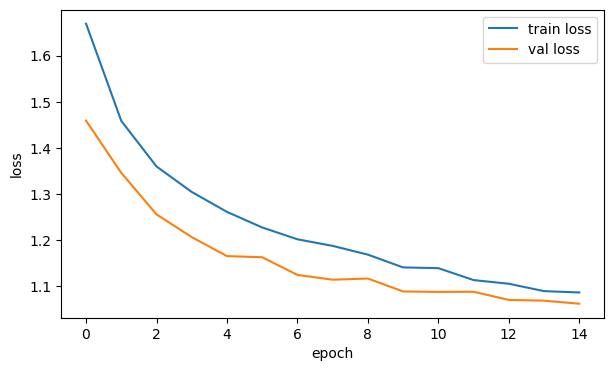

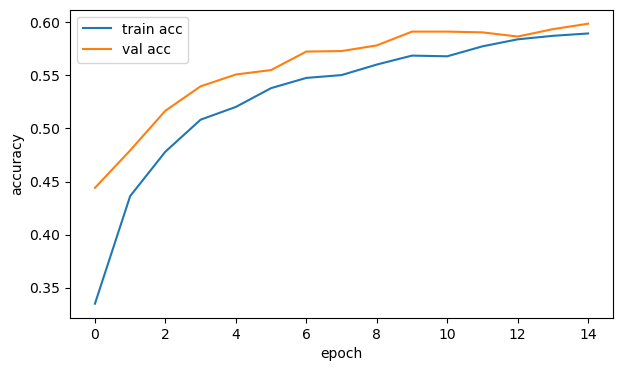

In [12]:
# PLOTS

plt.figure(figsize=(7,4))
plt.plot(history["train_loss"], label="train loss")
plt.plot(history["val_loss"], label="val loss")
plt.legend()
plt.xlabel("epoch")
plt.ylabel("loss")
plt.show()

plt.figure(figsize=(7,4))
plt.plot(history["train_acc"], label="train acc")
plt.plot(history["val_acc"], label="val acc")
plt.legend()
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.show()

In [13]:
# TEST

test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Test loss: {test_loss:.4f} | Test acc: {test_acc:.4f}")


Test loss: 1.0789 | Test acc: 0.5949
